In [2]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#read data & set theme
df = pd.read_csv('../data/Loan_Default.csv')
sns.set_theme(style='whitegrid')

In [4]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


# I. Biến mục tiêu (imbalanced data) 

Số lượng vỡ nợ: 36639
Tỷ lệ vỡ nợ: 24.64%


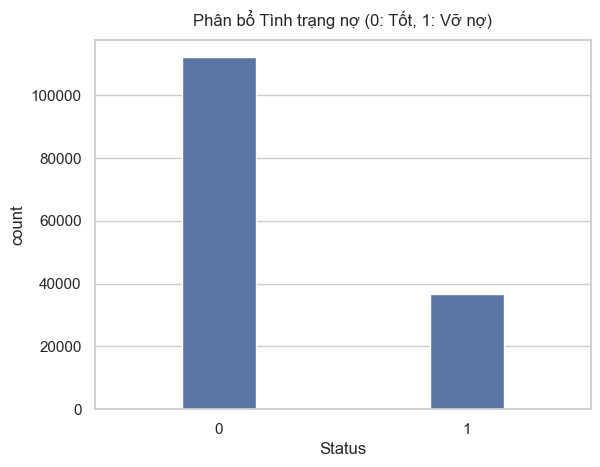

In [5]:
#Tính tỷ lệ phần trăm vỡ nợ
target = sns.countplot(data=df, x='Status', width=0.3)
target.set_title("Phân bổ Tình trạng nợ (0: Tốt, 1: Vỡ nợ)",pad=10)
total = len(df)
status_counts = df['Status'].value_counts()
rate = (status_counts[1] / (status_counts[0] + status_counts[1])) * 100
print(f"Số lượng vỡ nợ: {status_counts[1]}")
print(f"Tỷ lệ vỡ nợ: {rate:.2f}%")

- Dữ liệu có sự mất cân bằng nghiêm trọng(24.64% vỡ nợ, 75.36% tốt)
- Status là biến phân loại(Categorical), nên countplot giúp phát hiện độ lệch giữa 2 nhóm (0 và 1) bằng cách nhìn độ cao của cột.

Text(0, 0.5, 'Tỷ lệ phần trăm')

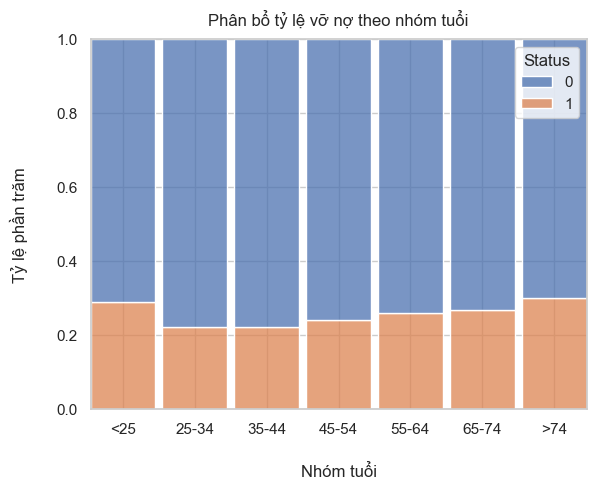

In [6]:
#Phân bổ tỷ lệ vỡ nợ theo nhóm tuổi
age_order= ["<25", "25-34","35-44","45-54","55-64","65-74",">74"]
df['age'] = pd.Categorical(df['age'], categories=age_order,ordered=True)
age_status = sns.histplot(data=df, x='age', hue='Status', multiple='fill',shrink=0.9)
age_status.set_title("Phân bổ tỷ lệ vỡ nợ theo nhóm tuổi",pad =10)
age_status.set_xlabel("Nhóm tuổi",labelpad=20)
age_status.set_ylabel("Tỷ lệ phần trăm",labelpad=20)

- Nhóm tỷ lệ vỡ nợ(màu cam) ở 2 nhóm tuổi <25 và >74 cao hơn các nhóm tuổi còn lại => Những người quá trẻ hoặc quá già có tỷ lệ vỡ nợ cao hơn. Trong khi đó, tỷ lệ vỡ nợ có xu hướng tăng lên theo các nhóm tuổi từ 25-74
- Histplot fill giúp so sánh tỷ lệ rủi ro công băng giữa các nhóm tuổi (Bỏ qua số lượng)

Text(0, 0.5, 'Số lượng hồ sơ')

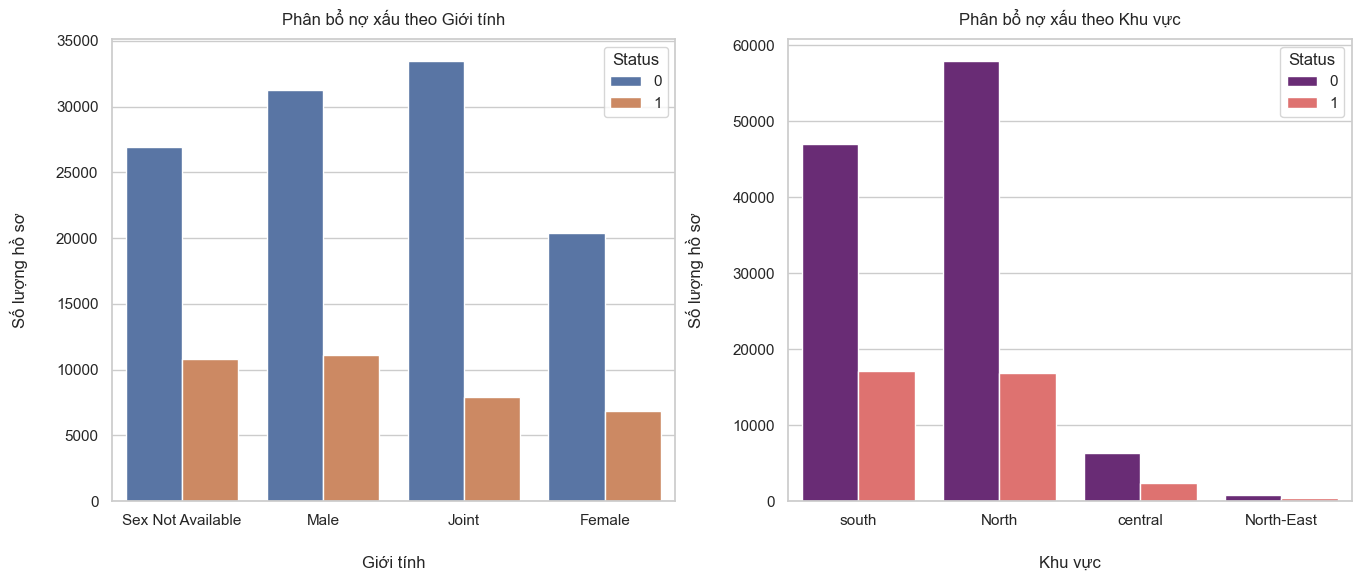

In [7]:
#Phân bổ tình trạng vỡ nợ theo giới tính và khu vực
#Biểu đồ 1: Gender
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df, x='Gender', hue='Status', ax=axes[0])
axes[0].set_title("Phân bổ nợ xấu theo Giới tính",pad=10)
axes[0].set_xlabel("Giới tính", labelpad=20)
axes[0].set_ylabel("Số lượng hồ sơ",labelpad=20)
# Biểu đồ 2: Region
sns.countplot(data=df, x='Region', hue='Status', ax=axes[1],palette='magma')
axes[1].set_title("Phân bổ nợ xấu theo Khu vực",pad=10)
axes[1].set_xlabel("Khu vực",labelpad=20)
axes[1].set_ylabel("Số lượng hồ sơ",labelpad=20)

1. Phân tích theo giới tính
- Nhóm an toàn nhất: Hồ sơ vay chung (Joint) chiếm số lượng lớn nhất và có tỷ lệ vỡ nợ (cột cam) thấp hơn so với các nhóm khác.
- Nhóm rủi ro nhất: Nhóm khách hàng Nam (Male) và nhóm không có thông tin giới tính (Sex Not Available) có tỷ lệ cột màu cam khá cao.
- Vấn đề dữ liệu: Một lượng lớn hồ sơ nàm ở cột "Sex Not available" cần được làm sạch để tránh thông tin sai lệch.

2. Phân tích theo khu vực
- Thị trường chủ yếu: Miền Bắc (North) và miền Nam (south) là hai khu vực chiếm số lượng hồ sơ áp đảo => là hai thị trường mục tiêu chính của mô hình.
- Rủi ro cao tại miền Nam: Tỷ lệ vỡ nợ ở miền Nam có xu hướng cao hơn miền Bắc vì tổng hồ sơ ít hơn miền Bắc.
- Dữ liệu ít: Khu vực central và North-East có dữ liệu ít khiến việc xác định khó khăn hơn.

# II. Outliers & missing values

In [8]:
#Phân tích cột dtir1 (Tỷ lệ nợ / thu nhập) nhằm xác định các outliers
#Boxplot để xem phân phối số tiền
df.dtir1

0         45.0
1          NaN
2         46.0
3         42.0
4         39.0
          ... 
148665    48.0
148666    15.0
148667    49.0
148668    29.0
148669    44.0
Name: dtir1, Length: 148670, dtype: float64

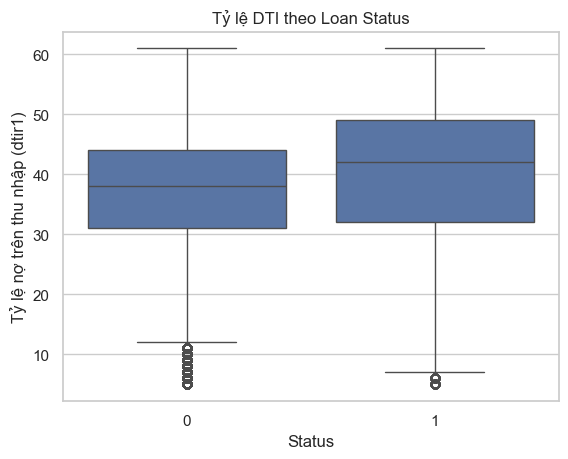

In [9]:
group_by_status_0 = df[df["Status"] == 0]["dtir1"]
group_by_status_1 = df[df["Status"] == 1]["dtir1"]

sns.boxplot(x="Status", y="dtir1", data=df)

plt.title("Tỷ lệ DTI theo Loan Status")
plt.xlabel("Status")
plt.ylabel("Tỷ lệ nợ trên thu nhập (dtir1)")

plt.show()

1. Biểu đồ trên có 2 hộp đại diện cho 2 nhóm với các trục:  
Trục x:  
- 0: Khách hàng không vỡ nợ
- 1: Khách hàng vỡ nợ  
Trục y: đại diện cho tỉ lệ nợ trên thu nhập (dtir1)

2. Đường giữ hộp là Median(trung vị)  
- Cột status 0: quan sát thấy rơi vào khoảng 37-39  
- Cột status 1: quan sát thấy rơi vào khoảng 42-43  
Điều này có nghĩa là:  
Nhóm vỡ nợ có tỷ lệ (nợ/thu nhập) cao hơn hẳn so với nhóm không vỡ nợ

3. Quan sát 2 hộp (Tư phân vị Q1 -> Q3 khoảng 50% dữ liệu)  
- Quan sát thấy hộp có nhóm Status 1 cao hơn hẳn  
- Điều này có nghĩa là: Phần lỡn người vỡ nợ có dtir cao hơn

4. Các chấm tròn (Outlier)
- Các chấm tròn xuất hiện ở phía dưới giao động khoảng từ 5 - 10 (dtir1) => Giá trị bất thường  
- Quan sát thấy các chấm tròn xuất hiện ở cả 2 status => Điều này có nghĩa là tỉ lệ dtir thấp thì không phải không có khả năng vỡ nợ  
- Ngoài ra các chấm tròn xuất hiện nhiều ở nhóm status 0 cho thấy rằng nhóm này có nhiều khách hàng có tỉ lệ nợ trên thu nhập rất thấp

5. Insign
- Boxplot trên đã thể hiện rõ người vay với Status = 1 dự kiến có tỉ lệ dtir cao hơn hẳn so với những người vay có Status = 0  
- Giá trị trung vị DTI (median) của nhóm vỡ nợ là cao hơn, điều này cho thấy rằng khách hàng với tỉ lệ nợ so với thu nhập của bản thân quá cao thì có khả năng cao là vỡ nợ  
- Tuy nhiên vì sự xuất hiện của các giá trị ngoại lai (outlier) cho thấy rằng nguy cơ vỡ nợ còn bị ảnh hưởng bởi các yếu tố bổ sung ngoài DTI


Giá trị số tiền vay lớn nhất: 3576500


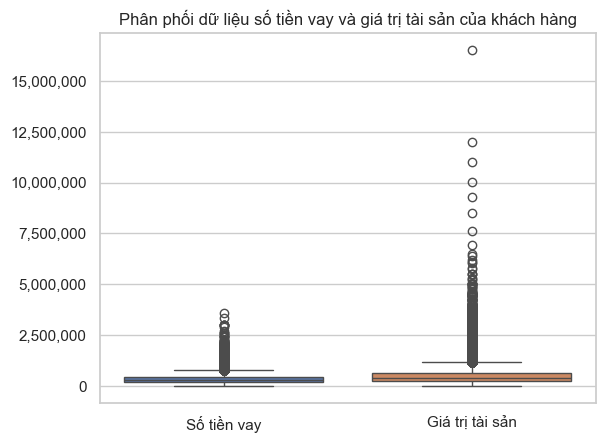

In [10]:
#Phân tích cột loan_amount & property_value nhằm xác định quy mô khoản vay, mức vay tối đa
#Boxplot để xem phân phối số tiền
sns.boxplot(data=df[['loan_amount', 'property_value']])

plt.title("Phân phối dữ liệu số tiền vay và giá trị tài sản của khách hàng")
plt.xticks([0, 1], ['Số tiền vay', 'Giá trị tài sản'])
plt.gca().get_yaxis().set_major_formatter('{x:,.0f}')
max_loan_data = df["loan_amount"].max()
print("Giá trị số tiền vay lớn nhất:", max_loan_data)
plt.show()

1. Phân tích biểu đồ  
- Nhìn vào biểu đồ ta thấy được 2 cột là:  
Cột x:  
+ Hộp bên trái là loan_amount (Số tiền vay)
+ Hộp bên phải property_value (Giá trị tài sản)  
Cột y: Chứa giả trị về số tiền 

2. Ý nghĩa từng phần giá trị
- Mỗi hộp đều có 3 phần: Đáy hộp (Q1 25% dữ liệu, Q3 75% dữ liệu, Đường giữa hộp là: Median(trung vị))
- Cả hộp chứa 50% dữ liệu trung tâm (Q1 -> Q3)

3. Các chấm tròn phía trên (outliers)
- Các chấm tròn outliers là các giá trị bất thường
- Các giá trị này đại diện cho 1 khoản vay cực lớn hoặc giá trị tài sản cực lớn

4. Insigh
- Thông qua biểu đồ trên, ta quan sát thấy được phần lớn giá trị loan_amount (số tiền vay) tập trung ở khoản khá thấp dao động từ khoảng trên dưới 100.000 đến dưới 5.000.000 so với (giá trị tài sản) property_value
- Giá trị property_value cao hơn hẳn so với khoản vay cho thấy rằng điều này vô cùng hợp lý vì các hệ thống ngân hàng chỉ cho vay số tiền tương ứng dựa trên 1 phần giá trị tài sản
- Biểu đồ xuất hiện khá nhiều outliers cho thấy rằng tồn tại 1 số khoản vay và giá trị tài sản khá lớn so với phần chung dữ liệu hiện có
- Mức vay tối đa dựa trên tài sản hiện có có thể quan sát được trên biểu đồ khoản hơn 3.500.000 1 tí (cụ thể là 3.576.500)

Số dòng bị thiếu dữ liệu: 39642
Tỷ lệ missing: 26.66%


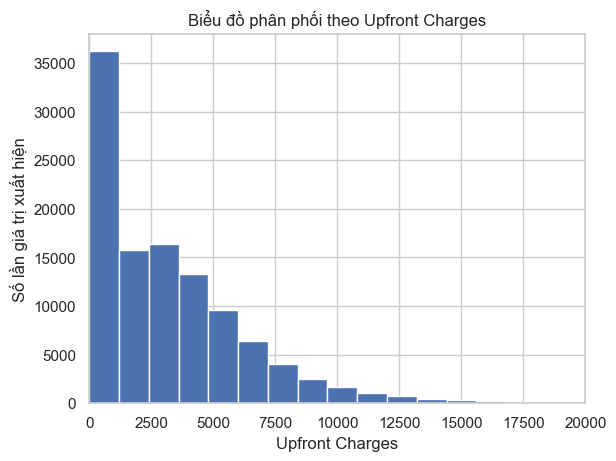

In [11]:
#Phân tích cột Upfront_changes nhằm đếm số dòng bị thiếu dữ liệu
#Histogram để xem phân phối dữ liệu
missing_count = df["Upfront_charges"].isnull().sum()
print(f"Số dòng bị thiếu dữ liệu: {missing_count}")
total_rows = len(df)
missing_percent = (missing_count / total_rows) * 100
print(f"Tỷ lệ missing: {missing_percent:.2f}%")

plt.hist(df["Upfront_charges"].dropna(), bins=50)
plt.xlim(0, 20000)
plt.title("Biểu đồ phân phối theo Upfront Charges")
plt.xlabel("Upfront Charges")
plt.ylabel("Số lần giá trị xuất hiện")
plt.show()

**Phân tích biểu đồ**
1. Phân phối dữ liệu 
- Ta quan sát được phần lớn dữ liệu tập trung ở vùng thấp phía bên trái (khoảng 0 -> 3000) và giảm dần về 0 ở phía bên phải khoảng trên 10000
- Điều đó chứng tỏ khi giá trị tăng lên thì tần suất xuất hiện giảm dần -> Đa số khách hàng chi trả chi phí upfront thấp

2. Dạng phân phối
- Biểu đồ có xu hướng lệch về bên phải có thể gọi là phân phối lệch phải
- Điều này lý giải được: Nhiều giá trị nhỏ, ít giá trị lớn.

3. Outlirs (Giá trị ngoại tệ)
- Ở phía từ 12500 -> 20000 có rất ít dữ liệu xuất hiện -> điều này có thể gọi là outliers
- Ngoài ra ở phía từ 0 -> khoảng 1250 cũng có rất ít dữ liệu cực lớn xuất hiện cũng có thể gọi là outliers

**Insign**
- Có khoảng 39642 dòng bị thiếu dữ liệu chiếm khoảng 26,66% trong cột Upfront_charges -> Điều này cho thấy rằng dữ liệu có 1 số lượng missing khá lớn và cần được xử lý trước khi đưa vào mô hình hoạt động
- Biếu đồ Histogram có xu hướng phân phối lệch phải
- Dựa vào Histogram cho thấy rằng lượng phân phối của Upfront_charges có dữ liệu tập trung nhiều đáng kể ở khoảng từ 0 -> khoảng trên dưới 1250 và giảm dần sau đó cho thấy hầu hết khách hàng phải trả upfront thấp
- Các khoảng outliers tồn tại trên 12500 vì dữ liệu xuất hiện với tần suất thấp ngoài ra cũng tồn tại ở khoảng từ 0 -> trên dưới 1250  


# III. Correlation & Năng lực tài chính

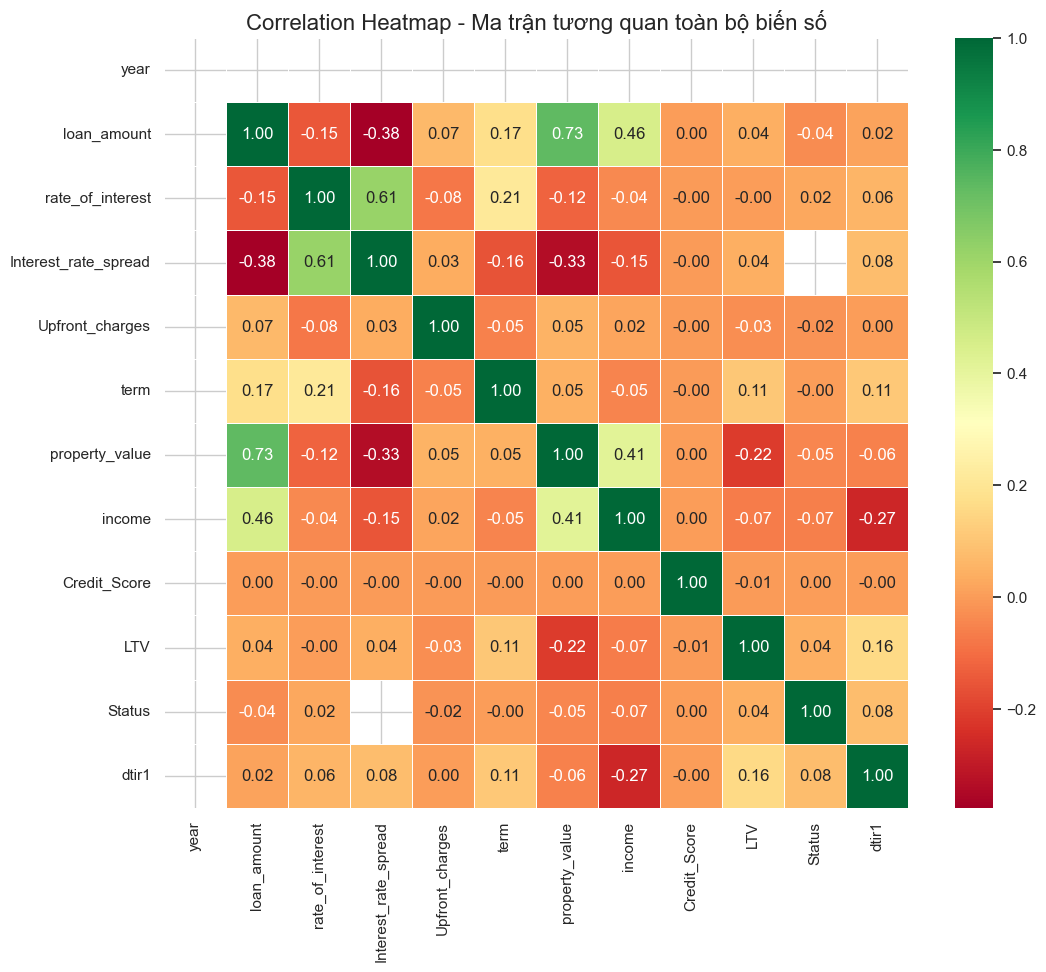

In [12]:
# nhận diện số 
numerical_df = df.select_dtypes(include=['float64', 'int64'])
# ma trận tương quan
cols_to_corr = [col for col in numerical_df.columns if col.lower() != 'id']
corr_matrix = numerical_df[cols_to_corr].corr()
#  Vẽ Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - Ma trận tương quan toàn bộ biến số', fontsize=16)
plt.show()

- Các cặp biến có độ tương quan mạnh :
|Variable 1 | Variable 2 | Correlation |
|---|---|---|
property_value       | loan_amount          | 0.73
interest_rate_spread | rate_of_interest     | 0.61
interest_rate_spread | loan_amount          | -0.38
property_value       | interest_rate_spread | -0,33
 



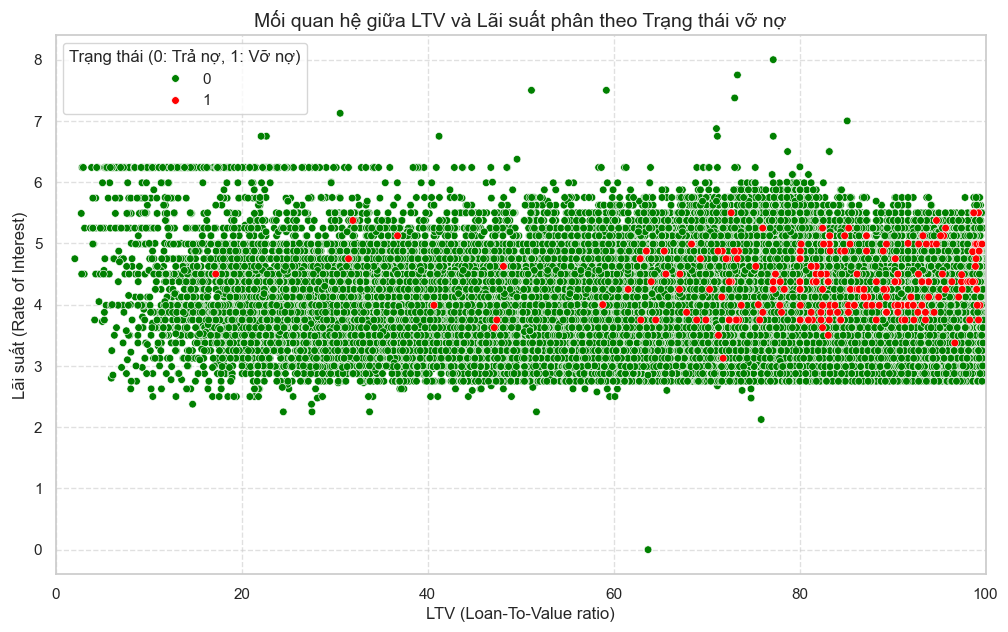

In [13]:
#Độ tương quan giữa LTV và rate_of_interest(Lãi suất)
df_plot = df.sort_values(by='Status', ascending=True)
plt.figure(figsize=(12, 7))
custom_palette = {0: "green", 1: "red"}
sns.scatterplot(data=df_plot, x='LTV', y='rate_of_interest', hue='Status', 
                palette=custom_palette, alpha=1, s=30)
plt.xlim(0, 100)
plt.title('Mối quan hệ giữa LTV và Lãi suất phân theo Trạng thái vỡ nợ', fontsize=14)
plt.xlabel('LTV (Loan-To-Value ratio)', fontsize=12)
plt.ylabel('Lãi suất (Rate of Interest)', fontsize=12)
plt.legend(title='Trạng thái (0: Trả nợ, 1: Vỡ nợ)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

- Những người có LTV cao (vay nhiều nhưng vốn tự có ít) sẽ bị ngân hàng áp mức lãi suất cao hơn . Vì các ngân hàng làm thế để gây áp lực lên con nợ để thu hồi vốn gấp

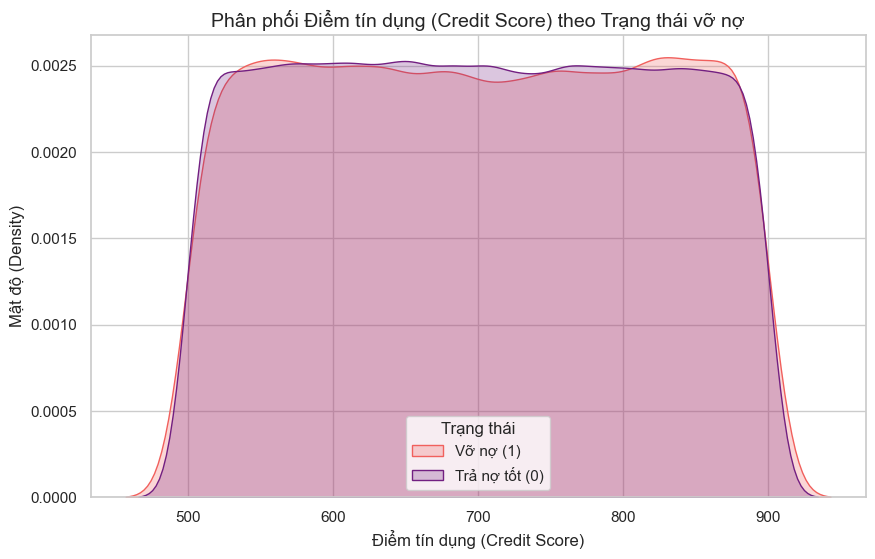

In [14]:
#Phân tích Credit Score (điểm tín dụng)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Credit_Score', hue='Status', fill=True, palette='magma', common_norm=False)
plt.title('Phân phối Điểm tín dụng (Credit Score) theo Trạng thái vỡ nợ', fontsize=14)
plt.xlabel('Điểm tín dụng (Credit Score)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend(title='Trạng thái', labels=['Vỡ nợ (1)', 'Trả nợ tốt (0)'])
plt.show()

# IV. Phân tích hợp đồng (Xem xét rủi ro từ các gói vay có điều khoản và mục đích khác nhau)

,Thời hạn khoản vay (tháng),Số lượng hồ sơ
0,96,194
1,108,33
2,120,510
3,132,93
4,144,263
5,156,174
6,165,1
7,168,82
8,180,12981
9,192,17


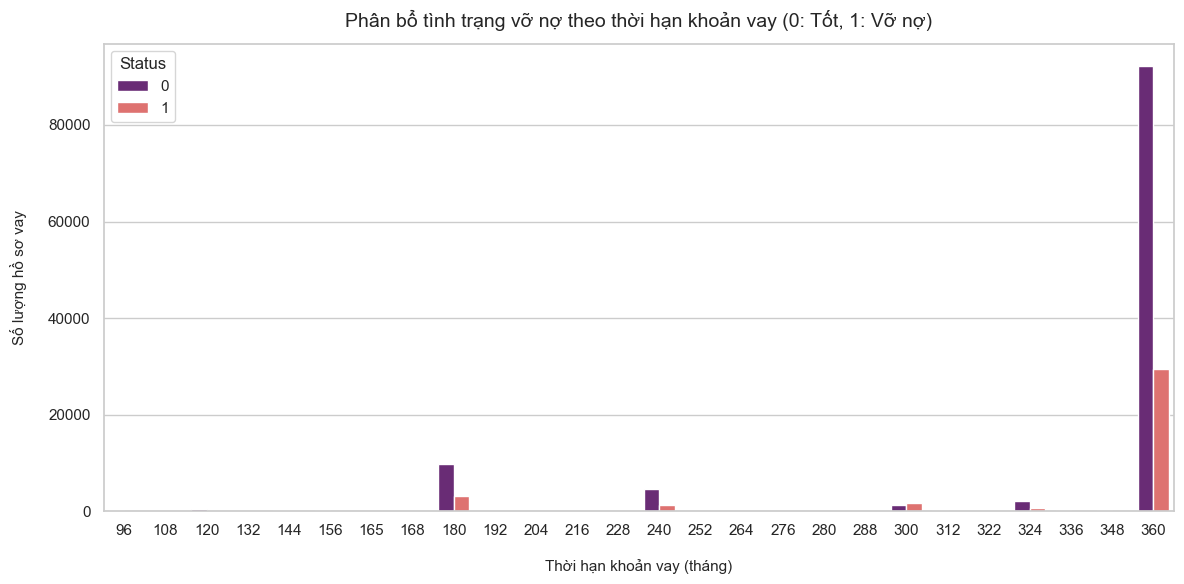

In [21]:
# Phân bổ tinh trạng vỡ nợ theo thời hạn khoản vay (term)
df_term = df.dropna(subset=['term']).copy()
df_term['term'] = df_term['term'].astype(int)

term_counts = df_term['term'].value_counts().sort_index().reset_index()
term_counts.columns = ['Thời hạn khoản vay (tháng)', 'Số lượng hồ sơ']

display(term_counts)

term_order = sorted(df_term['term'].unique())

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df_term,
    x='term',
    hue='Status',
    order=term_order,
    width=.75,
    palette='magma'
)

ax.set_title("Phân bổ tình trạng vỡ nợ theo thời hạn khoản vay (0: Tốt, 1: Vỡ nợ)", fontsize=14, pad=12)
ax.set_xlabel("Thời hạn khoản vay (tháng)", fontsize=11, labelpad=15)
ax.set_ylabel("Số lượng hồ sơ vay", fontsize=11, labelpad=15)

plt.tight_layout()
plt.show()

- Khoản vay **360 tháng (30 năm)** chiếm tỷ trọng lớn nhất với **121,685 hồ sơ**, tương đương khoảng **82% tổng số khoản vay**. Các mốc thời hạn khác như **180 tháng (12,981 hồ sơ)** và **240 tháng (5,859 hồ sơ)** có số lượng thấp hơn đáng kể, các khoản vay **300 tháng** và **324 tháng** cũng xuất hiện nhưng chiếm tỷ trọng tương đối nhỏ.

- Về tỷ lệ vỡ nợ, các khoản vay dài hạn có xu hướng rủi ro cao hơn so với một số khoản vay ngắn hạn. Cụ thể:
  - **180 tháng:** tỷ lệ vỡ nợ khoảng **24.30%**
  - **240 tháng:** khoảng **20.82%**
  - **300 tháng:** khoảng **56.56%**
  - **324 tháng:** khoảng **25.42%**
  - **360 tháng:** khoảng **24.21%**

- Đáng chú ý, nhóm **300 tháng** có tỷ lệ vỡ nợ **cao vượt trội (56.56%)** so với các nhóm còn lại, mặc dù số lượng hồ sơ của nhóm này tương đối nhỏ.

- Kết quả cho thấy các khoản vay có thời hạn từ **180–360 tháng** đều có tỷ lệ vỡ nợ ở mức đáng kể. Thời gian vay kéo dài có thể làm tăng khả năng chịu tác động của các yếu tố kinh tế như biến động thu nhập, lãi suất hoặc điều kiện thị trường.

- Do đó, biến **term** có ý nghĩa trong việc phản ánh mức độ rủi ro của khoản vay và có thể đóng vai trò quan trọng trong mô hình dự đoán nợ xấu.

,Không vỡ nợ,Vỡ nợ
loan_purpose,,
p1,25594,8935
p2,2191,1083
p3,41938,13996
p4,42209,12590


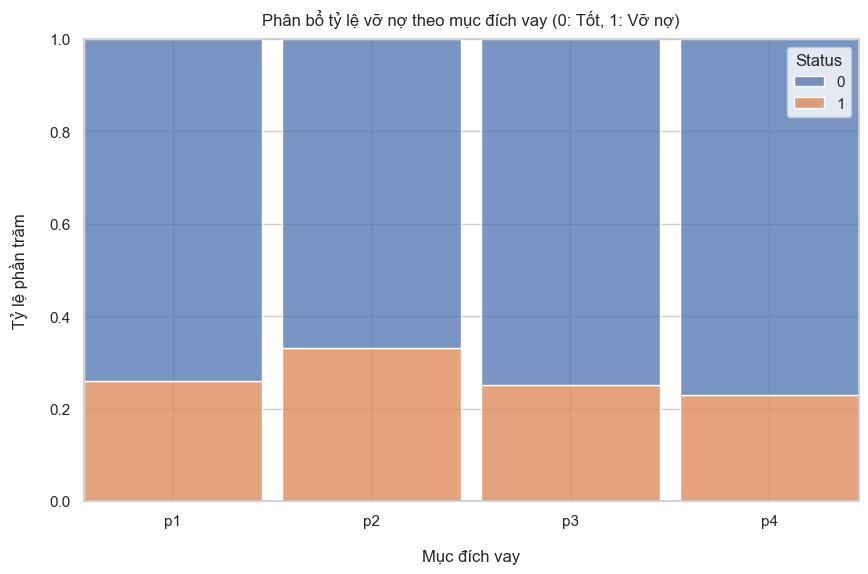

In [22]:
# Phân bổ tỷ lệ vỡ nợ theo mục đích vay (loan_purpose)
purpose_counts = df.groupby(['loan_purpose','Status']).size().unstack(fill_value=0)
purpose_counts.columns = ['Không vỡ nợ','Vỡ nợ']

display(purpose_counts)

purpose_order = ['p1','p2','p3','p4']

df['loan_purpose'] = pd.Categorical(
    df['loan_purpose'],
    categories=purpose_order,
    ordered=True
)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='loan_purpose',
    hue='Status',
    multiple='fill',
    shrink=0.9,
    hue_order=[0,1],
    discrete=True
)

plt.title("Phân bổ tỷ lệ vỡ nợ theo mục đích vay (0: Tốt, 1: Vỡ nợ)", pad=10)
plt.xlabel("Mục đích vay", labelpad=15)
plt.ylabel("Tỷ lệ phần trăm", labelpad=15)

plt.show()


- Xét về quy mô khoản vay, hai mục đích vay phổ biến nhất là **p3 (55,934 hồ sơ)** và **p4 (54,799 hồ sơ)**, chiếm phần lớn tổng danh mục cho vay. Trong khi đó, **p2 chỉ có 3,274 hồ sơ**, thấp hơn đáng kể so với các nhóm còn lại.

- Tuy nhiên, xét về **tỷ lệ vỡ nợ**, nhóm **p2** ghi nhận mức rủi ro cao nhất với khoảng **33.1%**, cao hơn so với:
  - **p1:** khoảng **25.9%**
  - **p3:** khoảng **25.0%**
  - **p4:** khoảng **23.0%**

- Như vậy, mặc dù số lượng khoản vay của nhóm **p2** tương đối nhỏ, nhưng tỷ lệ vỡ nợ lại cao hơn khoảng **8–10%** so với một số mục đích vay khác.

- Kết quả này cho thấy **loan_purpose** có khả năng phản ánh sự khác biệt về mức độ rủi ro tín dụng giữa các nhóm khách hàng dựa trên mục đích sử dụng vốn.


,Tổng số hồ sơ,Tỷ lệ vỡ nợ
business_or_commercial,,
b/c,20762,0.345439
nob/c,127908,0.230377


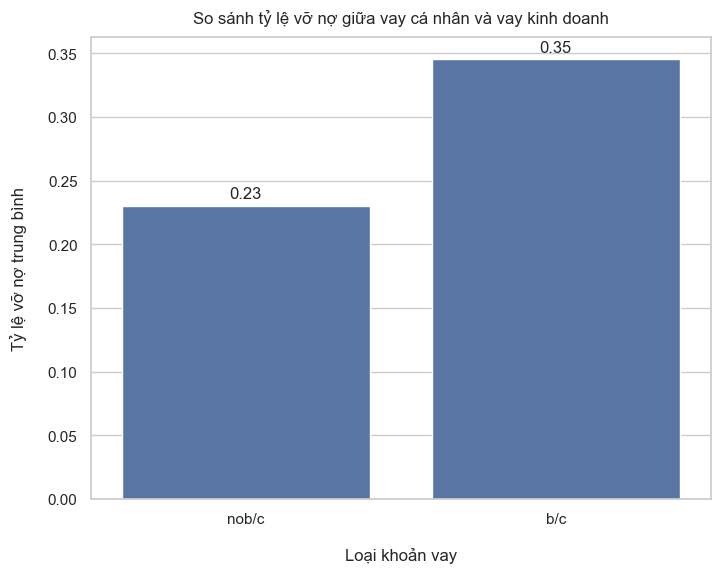

In [24]:
# So sánh rủi ro giữa khoản vay cá nhân và vay kinh doanh (business_or_commercial)
loan_type_counts = df.groupby('business_or_commercial')['Status'].agg(['count','mean'])
loan_type_counts.columns = ['Tổng số hồ sơ','Tỷ lệ vỡ nợ']

display(loan_type_counts)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df,
    x='business_or_commercial',
    y='Status',
    errorbar=None
)

ax.set_title("So sánh tỷ lệ vỡ nợ giữa vay cá nhân và vay kinh doanh", pad=10)
ax.set_xlabel("Loại khoản vay", labelpad=15)
ax.set_ylabel("Tỷ lệ vỡ nợ trung bình", labelpad=15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

- Các khoản vay **cá nhân/tiêu dùng (nob/c)** chiếm phần lớn với **127,908 hồ sơ**, trong khi **khoản vay phục vụ kinh doanh (b/c)** chỉ có **20,762 hồ sơ**.

- Tuy nhiên, xét về **tỷ lệ vỡ nợ**, nhóm vay phục vụ mục đích kinh doanh có mức rủi ro cao hơn đáng kể:
  - **b/c:** khoảng **34.5%**
  - **nob/c:** khoảng **23.0%**

- Chênh lệch giữa hai nhóm vào khoảng **11%**, cho thấy các khoản vay phục vụ hoạt động kinh doanh có mức độ rủi ro tín dụng cao hơn so với vay tiêu dùng cá nhân.

- Điều này có thể liên quan đến tính biến động của hoạt động kinh doanh, vốn phụ thuộc vào doanh thu và điều kiện thị trường, từ đó ảnh hưởng đến khả năng trả nợ của người vay.

,Không vỡ nợ,Vỡ nợ
interest_only,,
int_only,5168,1942
not_int,106863,34697


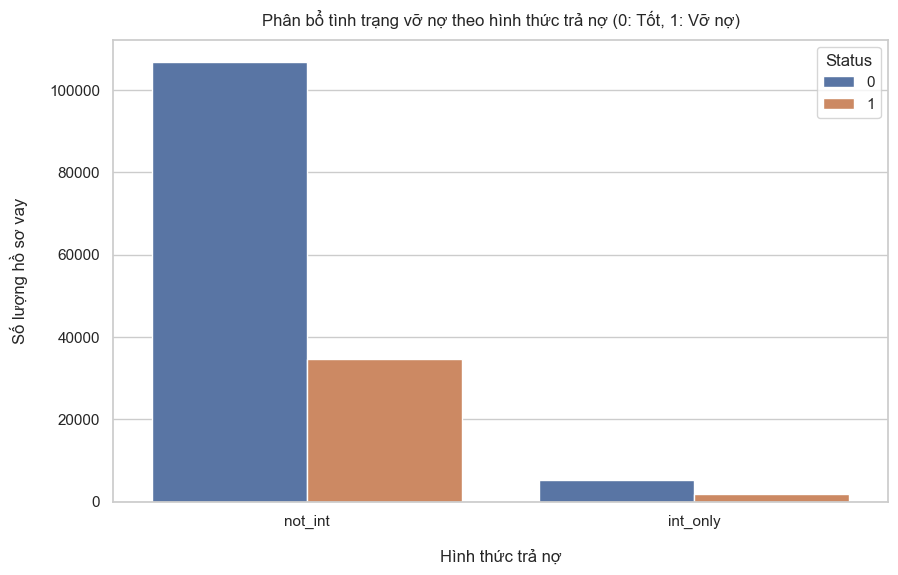

In [25]:
# Phân bổ tình trạng vỡ nợ theo hình thức trả nợ (interest_only)
interest_counts = df.groupby(['interest_only','Status']).size().unstack(fill_value=0)
interest_counts.columns = ['Không vỡ nợ','Vỡ nợ']

display(interest_counts)

plt.figure(figsize=(10, 6))

interest_status = sns.countplot(
    data=df,
    x='interest_only',
    hue='Status'
)

interest_status.set_title("Phân bổ tình trạng vỡ nợ theo hình thức trả nợ (0: Tốt, 1: Vỡ nợ)", pad=10)
interest_status.set_xlabel("Hình thức trả nợ", labelpad=15)
interest_status.set_ylabel("Số lượng hồ sơ vay", labelpad=15)

plt.show()


- Phần lớn khách hàng lựa chọn hình thức **trả cả gốc và lãi định kỳ (not_int)** với **141,560 hồ sơ**, trong khi hình thức **chỉ trả lãi hàng tháng (int_only)** chỉ có **7,110 hồ sơ**, chiếm tỷ trọng nhỏ trong tổng danh mục khoản vay.

- Xét về **tỷ lệ vỡ nợ** (cột màu cam), nhóm khách hàng chỉ trả lãi có mức rủi ro cao hơn:
  - **int_only:** khoảng **27.3%**
  - **not_int:** khoảng **24.5%**

- Chênh lệch giữa hai nhóm khoảng **3%**, cho thấy hình thức trả nợ chỉ trả lãi có thể gắn liền với mức rủi ro tín dụng cao hơn.

- Điều này có thể xuất phát từ đặc điểm của các khoản vay **interest-only**, trong đó phần gốc chưa được giảm trong giai đoạn đầu của hợp đồng, khiến dư nợ duy trì ở mức cao trong thời gian dài.